# Notebook 2: Cross-Repository Evaluation Overview

**Goal:** Describe the study population and overall evaluation scope before ranking any approach.

**Inputs:** `evaluation_attempts.csv`, `evaluation_overview.json`

**RQs addressed:** RQ1 (scope), RQ2 (scope)

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
required = DATA_DIR / 'evaluation_attempts.csv'
if not required.exists():
    raise FileNotFoundError(f'Missing required analysis CSV: {required}')
attempts  = pd.read_csv(required)
candidates = (pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
              if (DATA_DIR / 'evaluation_candidates.csv').exists() else pd.DataFrame())

overview_path = DATA_DIR / 'evaluation_overview.json'
overview = json.loads(overview_path.read_text()) if overview_path.exists() else {}

## 1. What Was Evaluated?

Study population: number of repositories, candidates (unique source methods), total attempts, and which models and tools participated. This establishes the scope before any outcome reporting.


In [2]:
scope = overview.get('scope', {})
scope_df = pd.DataFrame(list(scope.items()), columns=['metric', 'value'])
display(scope_df)

# Headline cards
for k, v in scope.items():
    print(f'  {k}: {v}')

# Attempts-per-repository share -- flags whether one repo dominates the
# attempt-weighted views (a synthetic smoke fixture can crowd out real repos).
if 'repo_name' in attempts.columns and len(attempts):
    counts = attempts['repo_name'].value_counts()
    share = (counts / counts.sum() * 100).round(1)
    repo_share = pd.DataFrame({'attempts': counts, 'share_%': share})
    print('\nAttempts per repository (attempt-weighted exposure):')
    display(repo_share)
    top_repo, top_share = share.idxmax(), share.max()
    if top_share >= 50:
        print(f'WARNING: {top_repo} contributes {top_share:.0f}% of all attempts. '
              'Attempt-weighted rates are dominated by this repository; prefer '
              'candidate-/repository-weighted views for headline claims.')


,metric,value
0,repositories_evaluated,2
1,candidates_evaluated,2
2,total_attempts,10
3,llm_attempts,6
4,agentic_attempts,4
5,models_evaluated,3
6,tools_evaluated,2


  repositories_evaluated: 2
  candidates_evaluated: 2
  total_attempts: 10
  llm_attempts: 6
  agentic_attempts: 4
  models_evaluated: 3
  tools_evaluated: 2

Attempts per repository (attempt-weighted exposure):


,attempts,share_%
repo_name,,
TestMap-Example,7,70.0
aspectcore-framework,3,30.0


## 2. How Much Was Generated?

Total generated tests by lane. Agentic attempts may produce multiple tests per invocation; LLM attempts always produce one. Use this alongside attempt counts to compute tests-per-attempt.


Generated test counts:
  generated_tests_total: 22
  generated_tests_llm: 6
  generated_tests_agentic: 16
  candidates_with_at_least_one_test: 2
  candidates_with_multiple_tests: 2


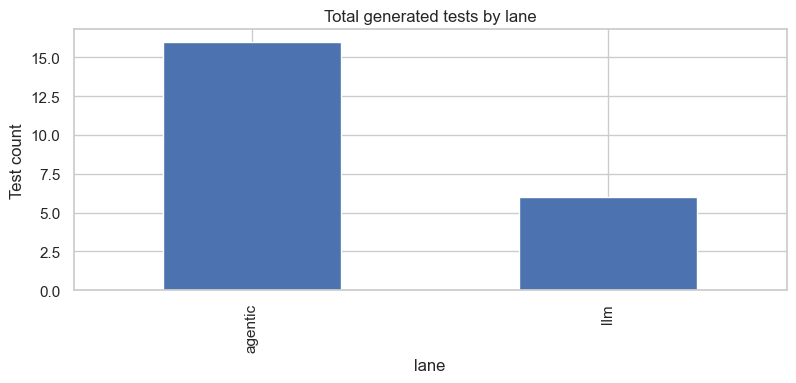

In [3]:
gen = overview.get('generated_tests', {})
print('Generated test counts:')
for k, v in gen.items():
    print(f'  {k}: {v}')

if 'generated_test_count' in attempts.columns and 'lane' in attempts.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    attempts.groupby('lane')['generated_test_count'].sum().plot(kind='bar', ax=ax)
    ax.set_title('Total generated tests by lane')
    ax.set_ylabel('Test count')
    plt.tight_layout()
    plt.show()

## 3. What Happened Overall?

Headline outcome counts across all repositories. `validated_successes` is the broad count (VEP + VLI); `validated_evidence_positive_attempts` is the narrower VEP count (passed AND metrics improved >= noise floor).

In [4]:
outcomes = overview.get('outcomes', {})
print('Outcome counts:')
for k, v in outcomes.items():
    print(f'  {k}: {v}')

if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    summary = attempts.groupby('lane')['validated_success'].agg(['sum', 'count', 'mean'])
    summary.columns = ['successes', 'total', 'rate']
    display(summary)

# Degeneracy guard: report the VEP/VLI split explicitly, even when a category is 0,
# so a missing class is never silently read as 'not applicable'.
vep_total = outcomes.get('validated_evidence_positive_attempts', 0)
vli_total = outcomes.get('validated_low_impact_attempts', 0)
print(f'\nValidated split:  VEP={vep_total}   VLI={vli_total}')
if vli_total == 0:
    print('  Note: ValidatedLowImpact (VLI) has no variance at current n -- '
          'validated_success == VEP for this dataset. The VLI scaffolding is retained '
          'for the larger evaluation where low-impact passes are expected to appear.')


Outcome counts:
  validated_successes: 4
  positive_impact_attempts: 4
  validated_evidence_positive_attempts: 4
  validated_low_impact_attempts: 0
  outcome_validatedevidencepositive_total: 4
  outcome_validatedevidencepositive_llm: 1
  outcome_validatedevidencepositive_agentic: 3
  outcome_validatedlowimpact_total: 0
  outcome_validatedlowimpact_llm: 0
  outcome_validatedlowimpact_agentic: 0
  outcome_failedevidencepositive_total: 4
  outcome_failedevidencepositive_llm: 4
  outcome_failedevidencepositive_agentic: 0
  outcome_validationfailed_total: 2
  outcome_validationfailed_llm: 1
  outcome_validationfailed_agentic: 1
  outcome_nochange_total: 0
  outcome_nochange_llm: 0
  outcome_nochange_agentic: 0
  outcome_skipped_total: 0
  outcome_skipped_llm: 0
  outcome_skipped_agentic: 0
  outcome_timedout_total: 0
  outcome_timedout_llm: 0
  outcome_timedout_agentic: 0
  outcome_toolfailed_total: 0
  outcome_toolfailed_llm: 0
  outcome_toolfailed_agentic: 0
  outcome_buildfailed_total: 0

,successes,total,rate
lane,,,
agentic,3,4,0.750000
llm,1,6,0.166667



Validated split:  VEP=4   VLI=0
  Note: ValidatedLowImpact (VLI) has no variance at current n -- validated_success == VEP for this dataset. The VLI scaffolding is retained for the larger evaluation where low-impact passes are expected to appear.


## 4. How Much Did Metrics Move?

Distribution of coverage and mutation deltas. Attempts with no measurement are excluded (missing delta = NA), so the distribution is conditional on output being produced. Red dashed line at 0 marks no change.

Metric movement:
  coverage_improvements: 9
  mutation_improvements: 3
  metric_improvements: 9
  mean_coverage_delta: 0.26489533011272137
  mean_mutation_delta: 2.0477618999254252


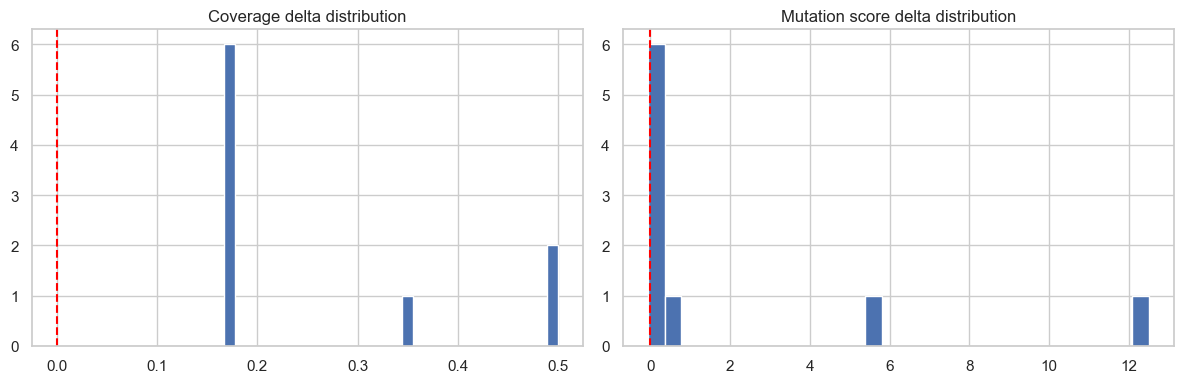

In [5]:
movement = overview.get('metric_movement', {})
print('Metric movement:')
for k, v in movement.items():
    print(f'  {k}: {v}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if 'coverage_delta' in attempts.columns:
    attempts['coverage_delta'].dropna().hist(bins=30, ax=axes[0])
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title('Coverage delta distribution')
if 'mutation_score_delta' in attempts.columns:
    attempts['mutation_score_delta'].dropna().hist(bins=30, ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title('Mutation score delta distribution')
plt.tight_layout()
plt.show()

## 5. What Did It Cost?

Total and median wall-clock runtime and token usage across the full evaluation. Provides the resource denominator for interpreting success rates in later notebooks.


In [6]:
cost = overview.get('cost', {})
print('Cost / runtime:')
for k, v in cost.items():
    print(f'  {k}: {v}')

if 'duration_seconds' in attempts.columns and 'lane' in attempts.columns:
    display(attempts.groupby('lane')['duration_seconds'].agg(['median', 'sum', 'count']))

Cost / runtime:
  total_duration_seconds: 4372.9300444
  median_duration_seconds: 217.67045645000002
  total_tokens: 698180


,median,sum,count
lane,,,
agentic,513.358822,2003.247521,4
llm,212.993013,2369.682523,6


## 6. How Complete Is the Data?

Missing-data heatmap: percentage of NA values per key outcome column per lane. Systematic missingness in coverage/mutation columns indicates the validation pipeline did not complete for those attempts, which affects the metric-movement distributions above.


Missingness:
  missing_coverage_before: 0
  missing_coverage_after: 1
  missing_mutation_before: 0
  missing_mutation_after: 1
  missing_tokens: 0
  missing_outcome_classification: 0
  missing_tool_attempt_id: 10


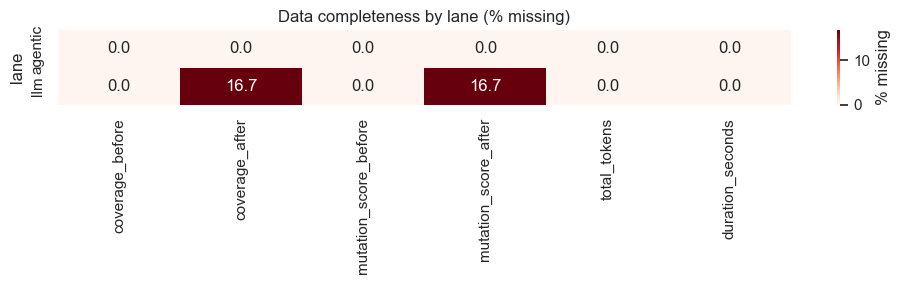

In [7]:
completeness = overview.get('data_completeness', {})
print('Missingness:')
for k, v in completeness.items():
    print(f'  {k}: {v}')

# Heatmap of null % by lane × column
key_cols = ['coverage_before', 'coverage_after', 'mutation_score_before',
            'mutation_score_after', 'total_tokens', 'duration_seconds']
present = [c for c in key_cols if c in attempts.columns]
if present and 'lane' in attempts.columns:
    null_pct = attempts.groupby('lane')[present].apply(lambda g: g.isna().mean() * 100)
    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(null_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% missing'})
    ax.set_title('Data completeness by lane (% missing)')
    plt.tight_layout()
    plt.show()

## 7. Outcome Classification by Lane

Full outcome taxonomy (ValidatedEvidencePositive, ValidatedLowImpact, FailedEvidencePositive, BuildFailed, TestsFailed, etc.) broken down by lane. More diagnostic than the binary success rate: shows where each lane's attempts most often fail.


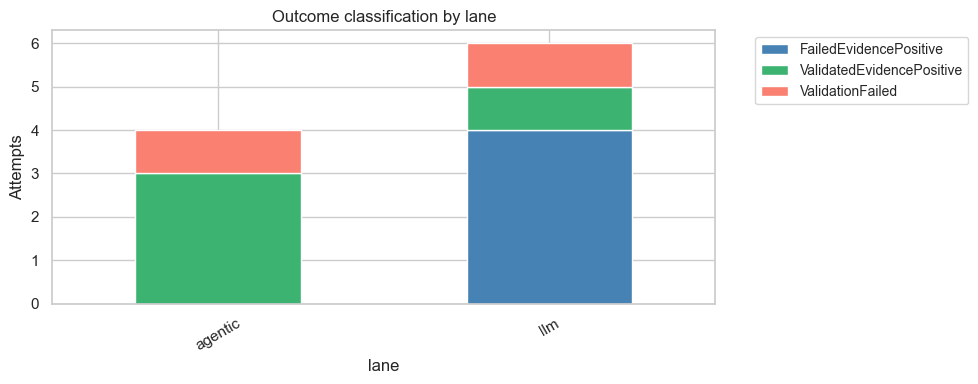


Outcome distribution (%):


outcome_classification,FailedEvidencePositive,ValidatedEvidencePositive,ValidationFailed
lane,,,
agentic,0.0,75.0,25.0
llm,66.7,16.7,16.7


In [8]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    outcome_classification_bar(attempts, group_col='lane', ax=ax)
    plt.tight_layout()
    plt.show()

    oc_table = attempts.groupby(['lane', 'outcome_classification']).size().unstack(fill_value=0)
    oc_pct = oc_table.div(oc_table.sum(axis=1), axis=0).mul(100)
    print('\nOutcome distribution (%):')
    display(oc_pct.round(1))
else:
    print('outcome_classification column not found.')

## 8. Source Method Complexity Profile

Distribution and per-repository median of structural metrics for the evaluated source methods -- the difficulty profile of the study population.

,count,mean,std,min,25%,50%,75%,max
source_method_cc,10.0,7.10,1.45,5.0,5.75,8.00,8.00,8.00
source_method_mi,10.0,64.90,1.45,64.0,64.00,64.00,66.25,67.00
source_method_coupling,10.0,3.60,0.97,3.0,3.00,3.00,4.50,5.00
source_method_dit,10.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
source_method_sloc,10.0,30.90,8.21,19.0,23.25,36.00,36.00,36.00
source_method_baseline_coverage,10.0,0.61,0.07,0.5,0.54,0.65,0.65,0.65


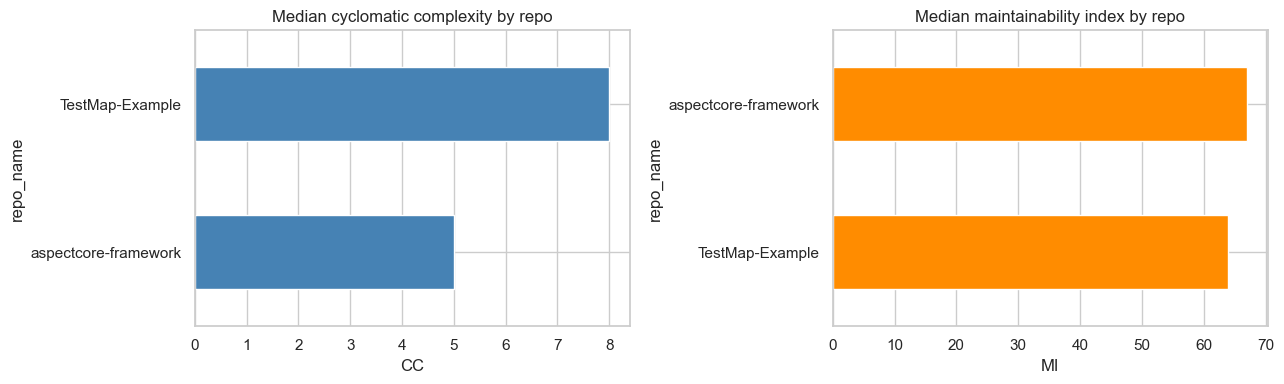

In [9]:
source_cols = [c for c in [
    'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_dit', 'source_method_sloc', 'source_method_baseline_coverage',
] if c in attempts.columns]

if source_cols:
    display(attempts[source_cols].describe().T.round(2))

    # Per-repo median complexity
    if 'repo_name' in attempts.columns and 'source_method_cc' in attempts.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        attempts.groupby('repo_name')['source_method_cc'].median().sort_values().plot(
            kind='barh', ax=axes[0], color='steelblue')
        axes[0].set_title('Median cyclomatic complexity by repo')
        axes[0].set_xlabel('CC')
        attempts.groupby('repo_name')['source_method_mi'].median().sort_values().plot(
            kind='barh', ax=axes[1], color='darkorange')
        axes[1].set_title('Median maintainability index by repo')
        axes[1].set_xlabel('MI')
        plt.tight_layout()
        plt.show()
else:
    print('Source method metric columns not found.')

## 9. Test Smell Overview

Aggregate count of test smell instances in baseline vs generated tests across all repositories. A higher generated smell rate signals systematic quality degradation in the tool outputs.


Baseline: total=0, attempts with smells=0 (0.0%)
Generated: total=13, attempts with smells=7 (70.0%)


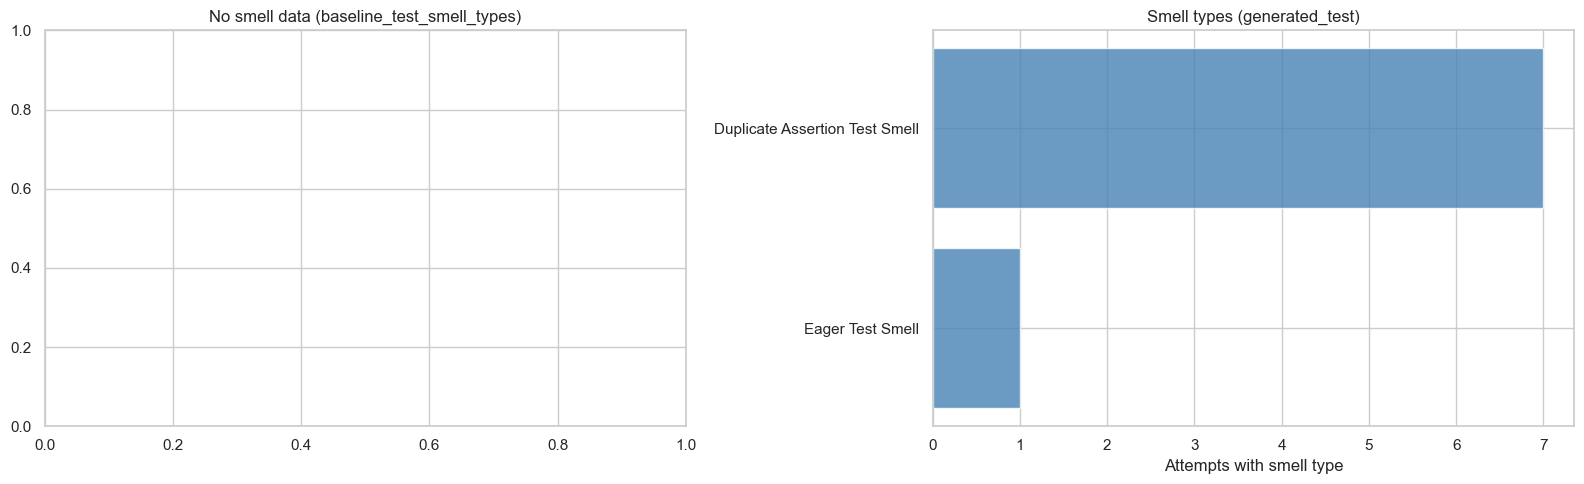

In [10]:
from analysis.plots import smell_type_breakdown

for count_col, types_col, label in [
    ('baseline_test_smell_count',  'baseline_test_smell_types',  'Baseline'),
    ('generated_test_smell_count', 'generated_test_smell_types', 'Generated'),
]:
    if count_col in attempts.columns:
        total = attempts[count_col].fillna(0).sum()
        with_smells = (attempts[count_col].fillna(0) > 0).sum()
        pct = with_smells / len(attempts) * 100
        print(f'{label}: total={int(total)}, attempts with smells={with_smells} ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
smell_type_breakdown(attempts, 'baseline_test_smell_types',  ax=axes[0])
smell_type_breakdown(attempts, 'generated_test_smell_types', ax=axes[1])
plt.tight_layout()
plt.show()

## 10. Timing and Token Usage

Median and total runtime by phase (generation vs validation) and lane. Token usage uses the candidate-level `effective_tokens` (LLM cumulative chain vs agentic total run) so the lanes are compared on the cost of a delivered result, not per repair step.

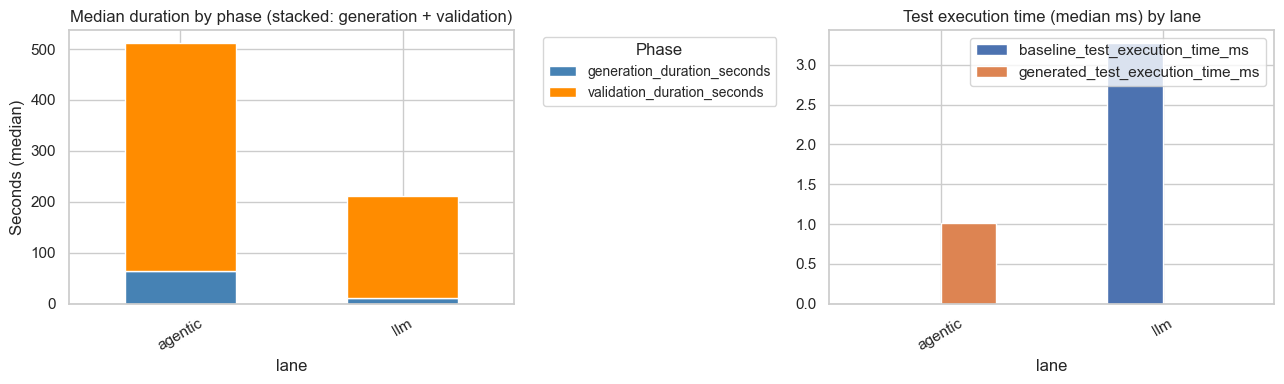

Effective tokens by lane (candidate-level):


,sum,median,count
lane,,,
agentic,630465.0,315232.5,2
llm,67715.0,33857.5,2


In [11]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(attempts, group_col='lane', ax=axes[0])
axes[0].set_title('Median duration by phase (stacked: generation + validation)')

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in attempts.columns]
if exec_cols:
    attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time (median ms) by lane')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Lane-fair token usage: candidate-level effective_tokens (do not sum raw per-step LLM tokens).
if not candidates.empty and 'effective_tokens' in candidates.columns:
    print('Effective tokens by lane (candidate-level):')
    display(candidates.groupby('lane')['effective_tokens'].agg(['sum', 'median', 'count']))
else:
    print('Candidate-level effective_tokens not available; rebuild datasets to populate it.')

## 11. Assertion Presence (RQ3 Guard)

A test can lift coverage while asserting nothing. This guard reports the share of validated
successes whose generated test contains **zero assertions** (coverage-theater). Assertions are
counted from the stored generated-test code (heuristic regex over C# assertion forms); the
`invocations` table does not yet parse generated tests. Zero zero-assertion successes is the
desired result.

In [12]:
if 'assertion_count' in attempts.columns:
    av = attempts[attempts['assertion_count'].notna()].copy()
    print(f'Attempts with assertion data: {len(av)}/{len(attempts)}')
    vs = av[av['validated_success'] == True]
    if len(vs):
        zero = int((vs['assertion_count'] == 0).sum())
        print(f'Validated successes: {len(vs)}; ZERO-assertion (coverage-theater): {zero} ({zero / len(vs):.0%})')
    display(av.groupby('lane')['assertion_count'].agg(['count', 'median', 'min', 'max']))
    produced = av[av['generated_test_n'].fillna(0) > 0]
    if len(produced):
        nz = int((produced['assertion_count'] == 0).sum())
        print(f'Generated-test attempts with zero assertions overall: {nz}/{len(produced)}')
else:
    print('assertion_count not available; rebuild datasets with --db to populate the RQ3 guard.')

Attempts with assertion data: 10/10
Validated successes: 4; ZERO-assertion (coverage-theater): 0 (0%)


,count,median,min,max
lane,,,,
agentic,4,9.5,5,13
llm,6,2.0,2,4


Generated-test attempts with zero assertions overall: 0/10


## 12. Mutation Operator Survival (RQ6)

Which mutation-operator classes do the existing test suites miss? `survival_rate` = Survived /
(Survived + Killed); higher means the suite fails to catch that kind of bug. This is the baseline
survival profile (before/after attribution to generated tests is deferred) -- it identifies where
generated tests have the most room to add value.

In [13]:
mut_path = DATA_DIR / 'mutation_operators.csv'
if mut_path.exists():
    mops = pd.read_csv(mut_path)
    for c in ['Killed', 'Survived']:
        if c not in mops.columns:
            mops[c] = 0
    mops['killable'] = mops['Killed'].fillna(0) + mops['Survived'].fillna(0)
    print(f'Mutation operators: {len(mops)} rows across {mops["repo_name"].nunique()} repos')
    top = mops[mops['killable'] >= 5].sort_values('survival_rate', ascending=False)
    print('Operator classes most often missed (survival_rate, >=5 killable mutants):')
    display(top[['repo_name', 'mutator_name', 'Killed', 'Survived', 'survival_rate']].head(12))
    by_repo = mops.groupby('repo_name')[['Killed', 'Survived']].sum()
    by_repo['survival_rate'] = by_repo['Survived'] / (by_repo['Killed'] + by_repo['Survived']).replace(0, float('nan'))
    print('Overall mutant survival by repo (baseline suites):')
    display(by_repo.round(3))
else:
    print('mutation_operators.csv not found; rebuild datasets with --db.')

Mutation operators: 41 rows across 2 repos
Operator classes most often missed (survival_rate, >=5 killable mutants):


,repo_name,mutator_name,Killed,Survived,survival_rate
24,dotnetcore-aspectcore-framework,Linq method mutation (OrderBy() to OrderByDesc...,0,14,1.000000
20,dotnetcore-aspectcore-framework,Linq method mutation (First() to FirstOrDefaul...,0,8,1.000000
25,dotnetcore-aspectcore-framework,Linq method mutation (Reverse() to AsEnumerabl...,0,6,1.000000
2,consulthunter-TestMap-Example,Null coalescing mutation (remove left),3,84,0.965517
26,dotnetcore-aspectcore-framework,Linq method mutation (Single() to SingleOrDefa...,1,21,0.954545
4,consulthunter-TestMap-Example,String mutation,77,223,0.743333
3,consulthunter-TestMap-Example,Statement mutation,76,177,0.699605
40,dotnetcore-aspectcore-framework,UnaryMinusExpression to UnaryPlusExpression mu...,14,30,0.681818
18,dotnetcore-aspectcore-framework,Linq method mutation (Concat() to Except()),14,29,0.674419
16,dotnetcore-aspectcore-framework,Linq method mutation (Any() to All()),21,33,0.611111


Overall mutant survival by repo (baseline suites):


,Killed,Survived,survival_rate
repo_name,,,
consulthunter-TestMap-Example,226,484,0.682
dotnetcore-aspectcore-framework,7448,2316,0.237
